
| Buổi | Chủ đề | Kỹ năng |
|:---:|--------|:-------:|
| Buổi 1 | Project Introduction & Setup | 🟢 |
| Buổi 2 | Business Questions & Dataset Design | 🟢 |
| Buổi 3 | Data Generation & Loading với Pandas | 🟡 |
| Buổi 4 | Data Cleaning & Validation | 🟡 |
| Buổi 5 | KPI & Cohort Retention Analysis | 🔵 |
| **📌 Buổi 6** | **Portfolio Reporting & Visualization** | **🔴** |
| Buổi 7 | Quiz & Submission Checklist | 🔴 |


---

<div align="center">

# 📁 Buổi 6 — Portfolio Reporting & Visualization

# Cohort & Retention Analytics Portfolio

*matplotlib charts · executive summary · README · quality gates · portfolio packaging*

</div>

---


## ⚠️ Phần 0 — Chuẩn Bị Môi Trường

> Buổi 6 **load dữ liệu từ `outputs/tables/`** — các file CSV đã được xuất ra ở Buổi 5. Đảm bảo đã chạy toàn bộ Buổi 5 trước khi bắt đầu.
>
> 4 file cần có sẵn:
> - `outputs/tables/monthly_kpi.csv`
> - `outputs/tables/channel_contribution.csv`
> - `outputs/tables/cohort_retention_matrix.csv`
> - `outputs/tables/cohort_revenue_matrix.csv`

**Kích hoạt môi trường ảo (nếu chưa):**

```powershell
cd C:\Users\ADMIN\cohort-retention-analytics
venv\Scripts\activate
```

---

### ⚡ Step 1 — Setup imports và đường dẫn


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# Phần 0: Setup & Imports
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.0f}".format)
sns.set_theme(style="whitegrid", palette="muted")

PROJECT_DIR      = Path.cwd().parent / "cohort-retention-analytics"
OUTPUT_TABLE_DIR = PROJECT_DIR / "outputs" / "tables"
OUTPUT_CHART_DIR = PROJECT_DIR / "outputs" / "charts"
REPORTS_DIR      = PROJECT_DIR / "reports"

# Tạo thư mục nếu chưa có
OUTPUT_CHART_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Setup complete")
print(f"   OUTPUT_TABLE_DIR : {OUTPUT_TABLE_DIR}")
print(f"   OUTPUT_CHART_DIR : {OUTPUT_CHART_DIR}")
print(f"   REPORTS_DIR      : {REPORTS_DIR}")
print(f"   Tất cả tồn tại   : {all([OUTPUT_TABLE_DIR.exists(), OUTPUT_CHART_DIR.exists(), REPORTS_DIR.exists()])}")



### ⚡ Step 2 — Load bảng phân tích từ Buổi 5

> Thay vì chạy lại toàn bộ code từ Buổi 3–5, Buổi 6 đọc thẳng từ file CSV đã export. Đây là cách làm việc thực tế: phân tích xong → lưu kết quả → notebook tiếp theo dùng lại mà không cần chạy lại từ đầu.


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# Step 2: Load 4 bảng từ outputs/tables/
# ═══════════════════════════════════════════════════════════════════════════

monthly_kpi = pd.read_csv(
    OUTPUT_TABLE_DIR / "monthly_kpi.csv",
    parse_dates=["order_month"],
)

channel_contribution = pd.read_csv(
    OUTPUT_TABLE_DIR / "channel_contribution.csv",
)

# Retention matrix có index là first_purchase_month → chỉ định index_col=0
retention_matrix = pd.read_csv(
    OUTPUT_TABLE_DIR / "cohort_retention_matrix.csv",
    index_col=0,
)
# Chuyển tên cột về số nguyên (CSV lưu là string "0", "1", ...)
retention_matrix.columns = retention_matrix.columns.astype(int)

cohort_revenue_matrix = pd.read_csv(
    OUTPUT_TABLE_DIR / "cohort_revenue_matrix.csv",
    index_col=0,
)
cohort_revenue_matrix.columns = cohort_revenue_matrix.columns.astype(int)

print("✅ Load thành công:")
print(f"   monthly_kpi          : {monthly_kpi.shape[0]} tháng × {monthly_kpi.shape[1]} cột")
print(f"   channel_contribution : {channel_contribution.shape[0]} kênh × {channel_contribution.shape[1]} cột")
print(f"   retention_matrix     : {retention_matrix.shape[0]} cohort × {retention_matrix.shape[1]} index")
print(f"   cohort_revenue_matrix: {cohort_revenue_matrix.shape[0]} cohort × {cohort_revenue_matrix.shape[1]} index")


**Kết quả mẫu**

![img6-1](images/images_buoi6/img6-1.png)


---

## 📊 Phần 1 — Visualization

### Tại sao cần chart?

Bảng số liệu đầy đủ thông tin nhưng khó truyền đạt nhanh cho người ngoài team (manager, client, nhà tuyển dụng đọc portfolio). Chart giúp:

| Mục đích | Chart phù hợp |
|----------|--------------|
| Xem doanh thu biến động theo thời gian | Line chart |
| So sánh đóng góp giữa các kênh | Bar chart |
| Nhìn tổng quan pattern retention | Heatmap |

**3 chart trong Buổi 6 là đủ cho một portfolio report chuyên nghiệp.**

> 📌 Copy từng đoạn code dưới đây vào **Section 8: Visualization** của `project_starter.ipynb`.

---

### ⚡ Step 3 — Chart 1: Monthly Revenue Trend

**Mục đích:** Cho người xem thấy doanh thu theo từng tháng — tháng nào tăng trưởng, tháng nào giảm, có pattern mùa vụ không.


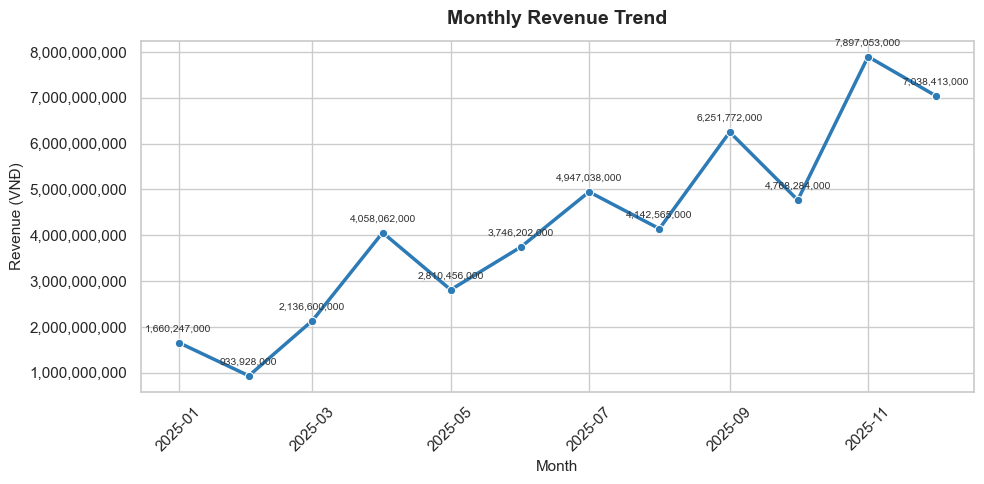

✅ Saved: c:\Users\ADMIN\cohort-retention-analytics\outputs\charts\monthly_revenue_trend.png


In [13]:

# ═══════════════════════════════════════════════════════════════════════════
# Chart 1: Monthly Revenue Trend
# → Copy vào Section 8: Visualization của project_starter.ipynb
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.ticker as mticker

fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=monthly_kpi,
    x="order_month",
    y="revenue",
    marker="o",
    linewidth=2.5,
    color="#2c7bb6",
    ax=axis,
)

# Thêm nhãn số trên mỗi điểm để dễ đọc
for _, row in monthly_kpi.iterrows():
    axis.annotate(
        f"{row['revenue']:,.0f}",
        xy=(row["order_month"], row["revenue"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=7.5,
        color="#333333",
    )

axis.set_title("Monthly Revenue Trend", fontsize=14, fontweight="bold", pad=12)
axis.set_xlabel("Month", fontsize=11)
axis.set_ylabel("Revenue (VNĐ)", fontsize=11)
axis.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_CHART_DIR / "monthly_revenue_trend.png", dpi=160)
plt.show()
print(f"✅ Saved: {OUTPUT_CHART_DIR / 'monthly_revenue_trend.png'}")


**Kết quả mẫu**

![img6-2](images/images_buoi6/img6-2.png)


### 🔍 Code này làm gì?

**`fig, axis = plt.subplots(figsize=(10, 5))`** — tạo một khung vẽ (fig) và một ô vẽ (axis). `figsize=(10, 5)` là chiều rộng × chiều cao tính bằng inch.

**`sns.lineplot(..., marker="o")`** — vẽ đường thẳng nối các điểm theo thứ tự tháng. `marker="o"` thêm chấm tròn tại mỗi điểm dữ liệu để dễ đọc.

**`axis.annotate(...)`** — thêm nhãn số ngay trên mỗi điểm, giúp người xem biết chính xác con số mà không cần đọc trục Y.

**`mticker.FuncFormatter`** — định dạng trục Y thành số có dấu phẩy ngăn hàng nghìn (`1,234,567`) thay vì số khoa học (`1.2e6`).

**`plt.savefig(..., dpi=160)`** — lưu chart ra file PNG với độ phân giải cao. `dpi=160` là đủ cho portfolio (màn hình và in A4).

---

> 💡 **Điền insight sau khi chạy:** Nhìn vào chart, viết 1 câu nhận xét cụ thể:
> *Ví dụ: "Doanh thu đạt đỉnh vào tháng 11 với X VNĐ (+Y% so với tháng 10), phản ánh tác động của chiến dịch Black Friday."*



---

### ⚡ Step 4 — Chart 2: Revenue by Acquisition Channel

**Mục đích:** So sánh đóng góp doanh thu giữa các kênh acquisition để biết kênh nào đang mang lại giá trị nhiều nhất.


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# Chart 2: Revenue by Acquisition Channel
# → Copy vào Section 8: Visualization của project_starter.ipynb (tiếp)
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.ticker as mticker

fig, axis = plt.subplots(figsize=(9, 5))

# Sắp xếp theo revenue giảm dần trước khi vẽ
df_chart = channel_contribution.sort_values("revenue", ascending=False)

bars = sns.barplot(
    data=df_chart,
    x="acquisition_channel",
    y="revenue",
    hue="acquisition_channel",  # Đổi màu mỗi cột (cần hue từ seaborn ≥ 0.13)
    palette="Blues_d",
    legend=False,
    ax=axis,
)

# Thêm nhãn revenue_share (%) trên đỉnh mỗi cột
for bar, (_, row) in zip(bars.patches, df_chart.iterrows()):
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + bar.get_height() * 0.01,
        f"{row['revenue_share']:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

axis.set_title("Revenue by Acquisition Channel", fontsize=14, fontweight="bold", pad=12)
axis.set_xlabel("Acquisition Channel", fontsize=11)
axis.set_ylabel("Revenue (VNĐ)", fontsize=11)
axis.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axis.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_CHART_DIR / "revenue_by_channel.png", dpi=160)
plt.show()
print(f"✅ Saved: {OUTPUT_CHART_DIR / 'revenue_by_channel.png'}")


**Kết quả mẫu**

![img6-3](images/images_buoi6/img6-3.png)


### 🔍 Code này làm gì?

**`sort_values("revenue", ascending=False)`** — sắp xếp kênh theo doanh thu trước khi vẽ. Bar chart có thứ tự từ cao xuống thấp dễ đọc hơn nhiều so với thứ tự chữ cái.

**`hue="acquisition_channel"` + `palette="Blues_d"`** — mỗi cột tự động có màu khác nhau trong bảng màu xanh, giúp phân biệt kênh dễ hơn khi nhìn lướt qua.

**`bars.patches`** — đây là danh sách các hình chữ nhật (cột) trong biểu đồ. Code duyệt qua từng cột để đặt nhãn `revenue_share` lên đỉnh mỗi cột.

**`bar.get_x() + bar.get_width() / 2`** — tính vị trí chính giữa của mỗi cột theo chiều ngang để đặt text đúng tâm.

---

> 💡 **Điền insight sau khi chạy:**
> *Ví dụ: "Kênh [TÊN] chiếm X% tổng revenue — gần gấp đôi kênh đứng thứ 2. Đây là kênh quan trọng nhất cần ưu tiên đầu tư."*



---

### ⚡ Step 5 — Chart 3: Cohort Retention Heatmap

**Mục đích:** Đây là chart quan trọng nhất trong portfolio — hiển thị toàn bộ retention matrix dưới dạng màu sắc, giúp người xem thấy ngay cohort nào giữ chân khách tốt và từ tháng nào khách bắt đầu "rời bỏ".


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# Chart 3: Cohort Retention Heatmap
# → Copy vào Section 8: Visualization của project_starter.ipynb (tiếp)
# ═══════════════════════════════════════════════════════════════════════════

fig, axis = plt.subplots(figsize=(11, 6))

# Vẽ heatmap — annot=True hiển thị số trong từng ô
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".0%",          # Hiển thị dạng phần trăm (45% thay vì 0.45)
    cmap="Blues",
    linewidths=0.5,     # Đường kẻ nhẹ giữa các ô
    linecolor="white",
    vmin=0,
    vmax=1,
    ax=axis,
)

axis.set_title(
    "Customer Retention by First Purchase Cohort",
    fontsize=14,
    fontweight="bold",
    pad=12,
)
axis.set_xlabel("Months Since First Purchase (Cohort Index)", fontsize=11)
axis.set_ylabel("First Purchase Month", fontsize=11)

# Xoay nhãn trục Y về ngang cho dễ đọc
axis.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_CHART_DIR / "cohort_retention_heatmap.png", dpi=160)
plt.show()
print(f"✅ Saved: {OUTPUT_CHART_DIR / 'cohort_retention_heatmap.png'}")


**Kết quả mẫu**

![img6-4](images/images_buoi6/img6-4.png)


### 🔍 Code này làm gì?

**`sns.heatmap(...)`** — vẽ bảng màu: mỗi ô là 1 giá trị retention_rate, màu xanh đậm = cao, trắng/nhạt = thấp. Toàn bộ cột 0 sẽ đồng màu xanh đậm nhất (100%).

**`annot=True, fmt=".0%"`** — hiển thị số bên trong mỗi ô, định dạng phần trăm không có số thập phân (`45%` thay vì `0.4500`).

**`vmin=0, vmax=1`** — cố định thang màu từ 0% đến 100%. Nếu không set, seaborn tự scale theo dữ liệu → các ô 40% và 50% trông giống nhau khi tối thiểu là 35%.

**`linewidths=0.5, linecolor="white"`** — thêm đường kẻ trắng mỏng giữa các ô giúp bảng trông gọn hơn, dễ đọc từng ô riêng biệt.

---

> 💡 **Điền insight sau khi chạy:**
> *Ví dụ: "Cohort tháng 1/2025 có retention rate tháng 2 là X% — cao nhất trong tất cả cohort. Ngược lại, cohort tháng 6 chỉ đạt Y% → có thể do chất lượng khách từ Summer Sale thấp hơn."*

---

### 📝 Sau khi vẽ xong 3 charts:

Mở thư mục `outputs/charts/` và kiểm tra 3 file PNG đã được lưu. Các file này sẽ được nhúng vào `executive_summary.md` ở bước tiếp theo.


**Kết quả mẫu**

![img6-5](images/images_buoi6/img6-5.png)


---

## 📄 Phần 2 — Executive Summary

### Executive Summary là gì và tại sao cần?

Executive Summary là tài liệu 1 trang tóm tắt toàn bộ project — dành cho người **không có thời gian đọc hết notebook**. Trong thực tế, đây thường là người quản lý, khách hàng hoặc nhà tuyển dụng.

**Một executive summary tốt phải trả lời được 4 câu hỏi trong vòng 2 phút đọc:**

| Câu hỏi | Section trong summary |
|---------|----------------------|
| Chúng ta đang phân tích gì? | Context |
| Kết quả cụ thể là gì? | Key Findings (có số liệu) |
| Kết quả này có nghĩa gì với business? | Business Implications |
| Nên làm gì tiếp theo? | Recommendations |
##
> **Lưu ý:** Executive summary **phải có số liệu cụ thể** — "doanh thu tăng" không đủ, phải là "doanh thu tháng 11 tăng 34% so với tháng 10".

---

### ⚡ Step 6 — Tạo file `executive_summary.md`

Code dưới đây tự động đọc số liệu từ bảng phân tích và điền vào template. Sau khi chạy, mở file `reports/executive_summary.md` và điền thêm nhận xét của bạn vào phần `[...]`.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Phần 2: Executive Summary
# → Copy vào Section 9: Executive Summary của project_starter.ipynb
# ═══════════════════════════════════════════════════════════════════════════

# ── Tự động lấy các số liệu chính ─────────────────────────────────────────
total_revenue      = monthly_kpi["revenue"].sum()
peak_month_row     = monthly_kpi.loc[monthly_kpi["revenue"].idxmax()]
peak_month         = str(peak_month_row["order_month"])[:7]
peak_revenue       = peak_month_row["revenue"]
avg_monthly_rev    = monthly_kpi["revenue"].mean()

top_channel_row    = channel_contribution.sort_values("revenue", ascending=False).iloc[0]
top_channel        = top_channel_row["acquisition_channel"]
top_channel_share  = top_channel_row["revenue_share"]
top_channel_aov    = top_channel_row["aov"]

# Retention index 1 của cohort có số liệu đầy đủ nhất (index 0 là oldest cohort)
first_cohort       = str(retention_matrix.index[0])[:7]
ret_month1         = retention_matrix.iloc[0, 1] if 1 in retention_matrix.columns else float("nan")
ret_month3         = retention_matrix.iloc[0, 3] if 3 in retention_matrix.columns else float("nan")

# ── Viết file executive_summary.md ────────────────────────────────────────
summary_path = REPORTS_DIR / "executive_summary.md"

summary_content = f"""# Executive Summary: Cohort & Retention Analytics

**Ngày:** {pd.Timestamp.today().strftime("%d/%m/%Y")}  
**Dataset:** Synthetic e-commerce — 650 khách hàng, 12 sản phẩm, ~2,057 đơn hàng (2025)

---

## 📌 Context

Dự án phân tích dữ liệu e-commerce tổng hợp nhằm đánh giá hiệu quả doanh thu, đóng góp theo kênh và chất lượng giữ chân khách hàng (retention) theo cohort.

**Business Question:** Kênh nào mang lại khách hàng chất lượng nhất? Cohort nào có retention tốt nhất và vì sao?

---

## 📊 Key Findings

1. **Revenue tổng:** {total_revenue:,.0f} VNĐ trong 12 tháng — trung bình {avg_monthly_rev:,.0f} VNĐ/tháng. Tháng đỉnh là **{peak_month}** với {peak_revenue:,.0f} VNĐ.

2. **Channel dominant:** Kênh **{top_channel}** chiếm {top_channel_share:.1%} tổng revenue với AOV {top_channel_aov:,.0f} VNĐ/đơn — [thêm nhận xét so sánh với các kênh còn lại].

3. **Cohort retention:** Cohort {first_cohort} có retention rate tháng 2 = {ret_month1:.0%}, tháng 4 = {ret_month3:.0%} — [thêm đánh giá: tốt/thấp so với benchmark industry ~25–30%].

---

## 💼 Business Implications

- **Growth:** [Nhận xét về xu hướng doanh thu — tăng trưởng đều hay phụ thuộc vào promotion?]
- **CRM:** Retention drop mạnh nhất xảy ra ở tháng thứ 2 (index 0→1) → đây là thời điểm vàng để re-engage khách hàng.
- **Marketing:** Nếu 1 kênh chiếm >40% revenue → concentration risk — cần đa dạng hoá nguồn traffic.

---

## ✅ Recommendations

1. **Triển khai re-engagement campaign trong 30 ngày sau mua đầu** vì retention drop lớn nhất ở index 0→1 ({ret_month1:.0%}).
2. **Tăng ngân sách cho kênh {top_channel}** vì kênh này có AOV cao nhất ({top_channel_aov:,.0f} VNĐ/đơn) — mỗi đồng acquisition mang về nhiều revenue hơn.
3. **[Recommendation 3]** vì [evidence từ data].

---

## ⚠️ Data Quality Caveat

- Dataset là dữ liệu **tổng hợp (synthetic)** — các pattern được thiết kế để có ý nghĩa phân tích nhưng không phản ánh thị trường thực.
- Đơn `cancelled` và `returned` được loại khỏi KPI và cohort analysis — chỉ tính đơn `completed`.
- Cohort 2–3 tháng cuối chưa đủ thời gian quan sát → không nên so sánh với cohort tháng đầu.

---

## 📁 Outputs

| File | Mô tả |
|------|-------|
| `outputs/tables/monthly_kpi.csv` | KPI theo tháng |
| `outputs/tables/channel_contribution.csv` | Revenue share theo kênh |
| `outputs/tables/cohort_retention_matrix.csv` | Retention matrix |
| `outputs/charts/monthly_revenue_trend.png` | Line chart doanh thu |
| `outputs/charts/revenue_by_channel.png` | Bar chart theo kênh |
| `outputs/charts/cohort_retention_heatmap.png` | Heatmap cohort |
"""

summary_path.write_text(summary_content, encoding="utf-8")
print(f"✅ Executive summary saved: {summary_path}")
print(f"   ({summary_path.stat().st_size} bytes)")
print()
print("📌 Mở file và điền số liệu thực vào các phần [...]")


**Kết quả mẫu**

![img6-6](images/images_buoi6/img6-6.png)

```----->```

![img6-7](images/images_buoi6/img6-7.png)


### 🔍 Code này làm gì?

Code trên gồm 2 phần:

**Phần 1 — Tự động lấy số liệu:**
- `monthly_kpi["revenue"].idxmax()` → tìm hàng có revenue cao nhất (tháng đỉnh)
- `channel_contribution.sort_values(...).iloc[0]` → lấy dòng đầu tiên sau sắp xếp = kênh đứng đầu
- `retention_matrix.iloc[0, 1]` → lấy giá trị ô hàng 0, cột 1 (cohort cũ nhất, tháng thứ 2)

**Phần 2 — Viết file Markdown:**
- `f"""..."""` là chuỗi f-string nhiều dòng — các biến `{total_revenue}`, `{top_channel}` được tự động thay bằng số thực khi chạy.
- `summary_path.write_text(...)` ghi chuỗi ra file `.md` với encoding UTF-8 (hỗ trợ tiếng Việt).

> **Sau khi chạy:** Mở `reports/executive_summary.md` trong VS Code (hoặc bất kỳ text editor nào), đọc qua và **điền thêm nhận xét** vào các phần `[...]`. Đây là phần bạn phải tự viết — code chỉ tạo khung và điền số, không thể thay phần phân tích của con người.



---

## 📘 Phần 3 — README Portfolio

### README là gì và tại sao quan trọng?

`README.md` là trang đầu tiên người xem thấy khi mở repo GitHub của bạn — giống như trang bìa của một báo cáo. Nếu README thiếu thông tin, người xem sẽ không biết cách chạy code, không biết kết quả là gì → ấn tượng kém dù notebook viết rất tốt.

**README cho portfolio Data Analyst cần có:**

| Phần | Mục đích |
|------|----------|
| Business Question | Người xem hiểu ngay bạn đang giải quyết vấn đề gì |
| Project Structure | Biết file nào ở đâu, không cần đoán |
| How to Run Locally | Tự chạy lại để kiểm chứng kết quả |
| Key Outputs | Biết xem file nào để thấy kết quả nhanh |
| Key Findings | 3 bullet points với số liệu — không đọc hết vẫn biết conclusion |

> ⚠️ **Lưu ý dự án này:** Không có web runtime — reviewer cần setup và chạy trên máy local. README phải hướng dẫn đủ để ai cũng làm được từ bước đầu.

---

### ⚡ Step 7 — Tạo file `README.md`


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# Phần 3: Tạo README.md cho portfolio
# → File này nằm ở root của project folder (cohort-retention-analytics/)
# ═══════════════════════════════════════════════════════════════════════════

readme_path = PROJECT_DIR / "README.md"

readme_content = f"""# Cohort & Retention Analytics Portfolio

> **Data Analyst Portfolio Project** — E-commerce customer retention analysis using Python & pandas.

---

## 📌 Business Question

Một doanh nghiệp e-commerce muốn hiểu:
1. Doanh thu đang tăng trưởng như thế nào theo tháng?
2. Kênh acquisition nào mang lại khách hàng có giá trị cao nhất?
3. Cohort khách hàng nào có retention rate tốt nhất? Sau bao nhiêu tháng thì retention ổn định?

---

## 📁 Project Structure

```
cohort-retention-analytics/
├── data/
│   ├── raw/                    # CSV gốc (customers, products, orders, order_items)
│   └── processed/              # clean_orders.csv sau khi cleaning
├── notebooks/
│   └── project_starter.ipynb  # Notebook phân tích chính (chạy từ đây)
├── outputs/
│   ├── tables/                 # CSV kết quả phân tích
│   └── charts/                 # PNG charts
├── reports/
│   └── executive_summary.md   # Tóm tắt kết quả cho stakeholder
├── src/
│   └── generate_ecommerce_dataset.py   # Script tạo dataset
├── requirements.txt
└── README.md
```

---

## 🚀 How to Run Locally

**Yêu cầu:** Python 3.9+ đã cài sẵn.

```powershell
# 1. Clone repo
git clone https://github.com/TranThiNgocVy/COHORT_and_RETENTION_ANALYTICS_PORTFOLIO.git
cd COHORT_and_RETENTION_ANALYTICS_PORTFOLIO

# 2. Tạo và kích hoạt virtual environment
python -m venv venv
venv\\Scripts\\activate          # Windows
# source venv/bin/activate      # macOS/Linux

# 3. Cài thư viện
pip install -r requirements.txt

# 4. Tạo dataset (nếu chưa có trong data/raw/)
python src/generate_ecommerce_dataset.py --output data/raw

# 5. Chạy notebook phân tích
jupyter notebook notebooks/project_starter.ipynb
# Chọn "Run All" hoặc chạy từng cell theo thứ tự
```

> ⚠️ Chạy các cell **theo đúng thứ tự từ trên xuống** — mỗi bước phụ thuộc vào bước trước.

---

## 📊 Key Outputs

| File | Mô tả |
|------|-------|
| `outputs/tables/monthly_kpi.csv` | Revenue, orders, active customers, AOV theo tháng |
| `outputs/tables/channel_contribution.csv` | Revenue share và AOV theo kênh acquisition |
| `outputs/tables/cohort_retention_matrix.csv` | % khách quay lại theo cohort × tháng |
| `outputs/charts/cohort_retention_heatmap.png` | Visualization retention (xem ngay không cần chạy code) |
| `reports/executive_summary.md` | Tóm tắt findings và recommendations |

---

## 🔑 Key Findings

1. **[Điền sau khi chạy]** — Tháng doanh thu cao nhất là ... với ... VNĐ (+...% so với trung bình).
2. **[Điền sau khi chạy]** — Kênh ... chiếm ...% tổng revenue với AOV cao nhất (...VNĐ/đơn).
3. **[Điền sau khi chạy]** — Cohort ... có retention tháng 2 = ...%, giảm về ...% ở tháng 4.

---

## 🛠️ Tech Stack

- **Python 3.9+** — pandas, numpy, matplotlib, seaborn
- **Jupyter Notebook** — phân tích interactive
- **Matplotlib/Seaborn** — visualization

---

## 📋 Rubric (tự đánh giá)

| Tiêu chí | Trọng số | Trạng thái |
|----------|:--------:|:----------:|
| Data quality & cleaning | 25% | ✅ |
| KPI/cohort tính đúng | 30% | ✅ |
| Insight gắn với business question | 25% | ⬜ Điền sau |
| Notebook/README dễ chạy lại | 10% | ✅ |
| Chart & summary rõ ràng | 10% | ✅ |
"""

readme_path.write_text(readme_content, encoding="utf-8")
print(f"✅ README saved: {readme_path}")
print(f"   ({readme_path.stat().st_size:,} bytes)")


**Kết quả mẫu**

![img6-8](images/images_buoi6/img6-8.png)

```----->```

![img6-9](images/images_buoi6/img6-9.png)


### 🔍 Code này làm gì?

Code dùng chuỗi f-string dài để tạo nội dung README, sau đó ghi ra file `README.md` ở thư mục gốc project. Điểm quan trọng:

- **Backtick trong f-string:** Dùng `\\` để escape khi cần. Trong code block markdown bên trong f-string, dùng `\\\\` thay vì `\\`.
- **`readme_path.write_text(..., encoding="utf-8")`** — ghi đè file nếu đã tồn tại. Mỗi lần chạy cell này sẽ tạo lại README từ đầu.

> 📌 **Sau khi chạy:** Mở `README.md` và điền số liệu thực vào phần **Key Findings** (3 dòng `[Điền sau khi chạy]`). Đây là phần cần con người đọc chart và nhận xét.

---

## 🔬 Phần 4 — Final Quality Gates

Quality gates là các kiểm tra cuối cùng trước khi nộp bài — đảm bảo tất cả deliverables đều có mặt và đúng format. Giống như checklist của phi công trước khi cất cánh.

### ⚡ Step 8 — Chạy Quality Gates


In [8]:

# ═══════════════════════════════════════════════════════════════════════════
# Phần 4: Final Quality Gates
# ═══════════════════════════════════════════════════════════════════════════

gates = {
    "Local reproducibility — README có hướng dẫn setup": (PROJECT_DIR / "README.md").exists(),
    "requirements.txt tồn tại": (PROJECT_DIR / "requirements.txt").exists(),
    "Data quality — clean_orders.csv đã được tạo": (PROJECT_DIR / "data" / "processed" / "clean_orders.csv").exists(),
    "KPI table — monthly_kpi.csv export thành công": (OUTPUT_TABLE_DIR / "monthly_kpi.csv").exists(),
    "KPI table — channel_contribution.csv export thành công": (OUTPUT_TABLE_DIR / "channel_contribution.csv").exists(),
    "Cohort logic — cohort_retention_matrix.csv export thành công": (OUTPUT_TABLE_DIR / "cohort_retention_matrix.csv").exists(),
    "Cohort logic — cohort_revenue_matrix.csv export thành công": (OUTPUT_TABLE_DIR / "cohort_revenue_matrix.csv").exists(),
    "Visualization — monthly_revenue_trend.png": (OUTPUT_CHART_DIR / "monthly_revenue_trend.png").exists(),
    "Visualization — revenue_by_channel.png": (OUTPUT_CHART_DIR / "revenue_by_channel.png").exists(),
    "Visualization — cohort_retention_heatmap.png": (OUTPUT_CHART_DIR / "cohort_retention_heatmap.png").exists(),
    "Communication — executive_summary.md tồn tại": (REPORTS_DIR / "executive_summary.md").exists(),
}

print("=" * 65)
print("  FINAL QUALITY GATES")
print("=" * 65)

all_pass = True
for gate, passed in gates.items():
    icon = "✅" if passed else "❌"
    print(f"  {icon}  {gate}")
    if not passed:
        all_pass = False

print("=" * 65)
if all_pass:
    print("  🎉 TẤT CẢ GATES ĐÃ PASS — Project sẵn sàng nộp!")
else:
    print("  ⚠️  Một số gate chưa pass — xem danh sách ❌ ở trên.")
print("=" * 65)


  FINAL QUALITY GATES
  ✅  Local reproducibility — README có hướng dẫn setup
  ✅  requirements.txt tồn tại
  ✅  Data quality — clean_orders.csv đã được tạo
  ✅  KPI table — monthly_kpi.csv export thành công
  ✅  KPI table — channel_contribution.csv export thành công
  ✅  Cohort logic — cohort_retention_matrix.csv export thành công
  ✅  Cohort logic — cohort_revenue_matrix.csv export thành công
  ✅  Visualization — monthly_revenue_trend.png
  ✅  Visualization — revenue_by_channel.png
  ✅  Visualization — cohort_retention_heatmap.png
  ✅  Communication — executive_summary.md tồn tại
  🎉 TẤT CẢ GATES ĐÃ PASS — Project sẵn sàng nộp!



### 🔍 Code này làm gì?

**`gates = {...}`** — một dictionary (bảng tra cứu) gồm: tên gate → kết quả kiểm tra (True/False). Mỗi giá trị là một expression kiểm tra file có tồn tại không (`.exists()`).

**`.exists()`** — phương thức của `pathlib.Path`: trả về `True` nếu file tồn tại trên đĩa, `False` nếu không. Không mở file, không đọc nội dung — chỉ kiểm tra sự tồn tại.

**Cách đọc kết quả:**
- `✅` — gate đã pass, file hoặc điều kiện được thoả mãn
- `❌` — gate chưa pass → cần quay lại cell liên quan và chạy lại

---

## 📦 Phần 5 — Chuẩn Bị Nộp Bài

### Folder structure khi nộp

Sau khi hoàn thành, thư mục project của bạn phải có đủ các file sau:

```
cohort-retention-analytics/
├── README.md                              ✅ Hướng dẫn chạy + key findings
├── requirements.txt                       ✅ Danh sách thư viện
├── src/
│   └── generate_ecommerce_dataset.py      ✅ Script tạo data
├── notebooks/
│   └── project_starter.ipynb              ✅ Notebook phân tích chính
├── outputs/
│   ├── tables/
│   │   ├── monthly_kpi.csv                ✅
│   │   ├── channel_contribution.csv       ✅
│   │   ├── cohort_retention_matrix.csv    ✅
│   │   └── cohort_revenue_matrix.csv      ✅
│   └── charts/
│       ├── monthly_revenue_trend.png      ✅
│       ├── revenue_by_channel.png         ✅
│       └── cohort_retention_heatmap.png   ✅
└── reports/
    └── executive_summary.md               ✅ Tóm tắt findings
```

### Cách đưa lên GitHub

```powershell
cd C:\Users\ADMIN\cohort-retention-analytics # địa chỉ thư mục của bạn

git init                         # Nếu chưa khởi tạo git
git add .
git commit -m "feat: complete cohort & retention analytics project"
git remote add origin https://github.com/TenGitCuaBan/Ten_Reposit.git
git push -u origin main
```

> 💡 **Thêm vào CV/LinkedIn:** *"Built an end-to-end e-commerce retention analysis in Python: data generation → cleaning → KPI → cohort retention matrix → executive summary. Tools: pandas, matplotlib, seaborn."*



---

## ✍️ Bài Tập Buổi 6

---

### 📝 Bài tập 1 — Cải thiện Chart

Thêm một đường tham chiếu (reference line) vào Monthly Revenue Trend chart, đánh dấu **doanh thu trung bình**:

```python
# Thêm vào sau sns.lineplot(...)
avg = monthly_kpi["revenue"].mean()
axis.axhline(y=avg, color="red", linestyle="--", linewidth=1.2, label=f"Avg: {avg:,.0f}")
axis.legend()
```
**Kết quả mẫu**

![img6-11](images/images_buoi6/img6-11.png)

**Câu hỏi:** `axhline` là gì? Tại sao thêm đường trung bình lại hữu ích cho người xem?

**💡 Đáp án:** `axhline` = "axis horizontal line" — vẽ một đường nằm ngang tại giá trị `y` chỉ định. Đường trung bình giúp người xem ngay lập tức thấy tháng nào **trên trung bình** (màu xanh cao hơn đường đỏ) và tháng nào **dưới trung bình** — không cần tính nhẩm.

---

### 📝 Bài tập 2 — Viết Key Findings thực tế

Sau khi chạy tất cả code và xem chart, mở `README.md` và điền **3 Key Findings** thực tế (có số liệu cụ thể từ dataset của bạn). Format:

```
1. Tháng [X] có revenue cao nhất: [Y] VNĐ (+[Z]% so với trung bình tháng).
2. Kênh [A] chiếm [B]% tổng revenue với AOV [C] VNĐ/đơn.
3. Cohort [tháng] có retention tháng 2 = [X]%, giảm về [Y]% ở tháng 4.
```
**Kết quả mẫu**

![img6-12](images/images_buoi6/img6-12.png)

**Câu hỏi:** Tại sao findings phải có số liệu cụ thể thay vì chỉ nói "doanh thu tăng" hay "retention tốt"?

**💡 Đáp án:** Số liệu cụ thể tạo **credibility** (độ tin cậy) — người đọc có thể kiểm chứng bằng cách chạy lại code. "Retention tháng 2 = 45%" là claim có thể verify; "retention tốt" là nhận xét mơ hồ không có giá trị. Trong Data Analytics, mọi finding đều phải gắn với một con số.

---

### 📝 Bài tập 3 — Tự review portfolio

Giả sử bạn là nhà tuyển dụng đọc portfolio này. Đọc lại `README.md` và `executive_summary.md`, trả lời:

**3a.** Sau 2 phút đọc README, bạn có biết cách tự chạy lại project trên máy mình không? Thiếu bước nào?

**3b.** Executive summary có đủ context để hiểu bối cảnh project không? Phần Recommendations có actionable (có thể thực hiện ngay) không?

**3c.** Nếu được thêm 1 chart nữa, bạn sẽ vẽ gì? Tại sao chart đó có giá trị?

**💡 Gợi ý đáp án 3c:** Một số option có giá trị:
- **AOV trend theo tháng** — xem AOV tăng/giảm song song với revenue, phát hiện nếu revenue tăng do có thêm đơn hay do đơn có giá trị cao hơn
- **Cohort Revenue Heatmap** — đã tạo `cohort_revenue_matrix`, chỉ cần vẽ heatmap tương tự chart 3 với `cmap="Blues"` và `fmt="{:,.0f}"`
- **Retention curve (line chart)** — vẽ retention theo cohort_index cho 3–4 cohort trên cùng 1 chart để so sánh shape của curve

---

### ✅ Checklist Buổi 6

- [ ] 3 charts đã lưu trong `outputs/charts/`: `monthly_revenue_trend.png`, `revenue_by_channel.png`, `cohort_retention_heatmap.png`
- [ ] Mỗi chart có title, axis labels và đơn vị rõ ràng
- [ ] `reports/executive_summary.md` đã được tạo và điền số liệu thực vào phần `[...]`
- [ ] `README.md` có đủ 5 phần: Business Question, Project Structure, How to Run, Key Outputs, Key Findings
- [ ] Key Findings trong README có ít nhất 1 con số cụ thể mỗi bullet
- [ ] Quality Gates chạy ra `✅ TẤT CẢ GATES ĐÃ PASS`
- [ ] Đã tự review README như một nhà tuyển dụng (Bài tập 3)

---

## 🎓 Tổng kết chuỗi học

| Buổi | Kỹ năng đạt được |
|:---:|----------------|
| 1 | Hiểu business context, setup môi trường Python |
| 2 | Đặt câu hỏi phân tích, thiết kế dataset schema |
| 3 | Tạo synthetic data với pandas, load và explore data |
| 4 | Data cleaning, validation, quality report |
| 5 | Monthly KPI, channel contribution, cohort retention matrix |
| 6 | Visualization, executive summary, README, portfolio packaging |

> 🎉 **Hoàn thành 6 buổi = 1 case study Data Analyst hoàn chỉnh**: business question → data → cleaning → KPI → cohort → recommendation → portfolio-ready deliverables.
